In [1]:
# import warnings
# warnings.filterwarnings('ignore')
import numpy as np
import pandas as pd
import scanpy as sc
import anndata as ad
import seaborn as sns
import scanpy.external as sce
import matplotlib.pyplot as plt
from matplotlib_venn import venn2, venn3, venn2_circles, venn3_circles
from anndata.experimental import AnnCollection
import harmonypy as hm
import scanorama
import bbknn
import celltypist
from celltypist import models
import gseapy as gp
import random 
import os
sc.settings.verbosity = 3
from gseapy.scipalette import SciPalette
sci = SciPalette()
NbDr = sci.create_colormap()

/home/iuliia_parshchikova/miniconda3/envs/sc_environment/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/home/iuliia_parshchikova/miniconda3/envs/sc_environment/lib/python3.11/site-packages/celltypist/classifier.py:11: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('scanpy')` instead
  from scanpy import __version__ as scv


In [2]:
datasets = []
for file, sample in [
    ('Gbl24_filtered.h5ad', 'Gbl24'),
    ('Gbl27_filtered.h5ad', 'Gbl27'),
    ('Gbl76_p3_filtered.h5ad', 'Gbl76_p3'),
    ('Gbl13_p48_filtered.h5ad', 'Gbl13_p48'),
    # ('adata_gbl13_p5.h5ad', 'Gbl13_p5'),
    ('Gbl17_filtered.h5ad', 'Gbl17'),
    ('Gbl28_filtered.h5ad', 'Gbl28'),
    ('Gbl6_filtered.h5ad', 'Gbl6'),
    ('Gbl75_filtered.h5ad', 'Gbl75'),
    ('Gbl76_p7_filtered.h5ad', 'Gbl76_p7'),
    # ('adata_gb75t.h5ad', 'Gb75t')
]:
    adata = sc.read_h5ad(f'adatas_new/{file}')
    adata.obs['sample'] = sample
    datasets.append(adata)

In [4]:
adata = ad.concat(datasets)
adata.obs_names_make_unique()
adata
print(adata.obs['sample'].value_counts())

sample
Gbl6         10870
Gbl76_p7      9598
Gbl28         6083
Gbl24         5856
Gbl17         4992
Gbl76_p3      3193
Gbl13_p48     3138
Gbl27         1558
Gbl75          802
Name: count, dtype: int64


In [5]:
anno = pd.read_excel("sample_info.xlsx")
anno = anno.set_index("sample")

obs = adata.obs.copy()
obs = obs.join(anno, on="sample") 
adata.obs = obs

In [7]:
adata_uncor = adata.copy()

In [8]:
# Calculate highly variable genes
sc.pp.normalize_total(adata_uncor, target_sum=1e4)
sc.pp.log1p(adata_uncor)
sc.pp.highly_variable_genes(adata_uncor)

# Do PCA
sc.pp.scale(adata_uncor) # z-score
sc.tl.pca(adata_uncor)

# Calculate kNN graph
sc.pp.neighbors(adata_uncor, n_pcs=30)

# Calculate leiden clusters
sc.tl.leiden(adata_uncor)

# Calculate UMAP
sc.tl.umap(adata_uncor)

normalizing counts per cell
    finished (0:00:00)
extracting highly variable genes
    finished (0:00:09)
--> added
    'highly_variable', boolean vector (adata.var)
    'means', float vector (adata.var)
    'dispersions', float vector (adata.var)
    'dispersions_norm', float vector (adata.var)
computing PCA
    with n_comps=50
    finished (0:02:04)
computing neighbors
    using 'X_pca' with n_pcs = 30
    finished: added to `.uns['neighbors']`
    `.obsp['distances']`, distances for each pair of neighbors
    `.obsp['connectivities']`, weighted adjacency matrix (0:00:31)
running Leiden clustering
    finished: found 21 clusters and added
    'leiden', the cluster labels (adata.obs, categorical) (0:00:09)
computing UMAP
    finished: added
    'X_umap', UMAP coordinates (adata.obsm)
    'umap', UMAP parameters (adata.uns) (0:01:07)


... storing 'sample' as categorical
... storing 'origin' as categorical
... storing 'mutations' as categorical
... storing 'mutations in matched tumor' as categorical
... storing 'matched status' as categorical


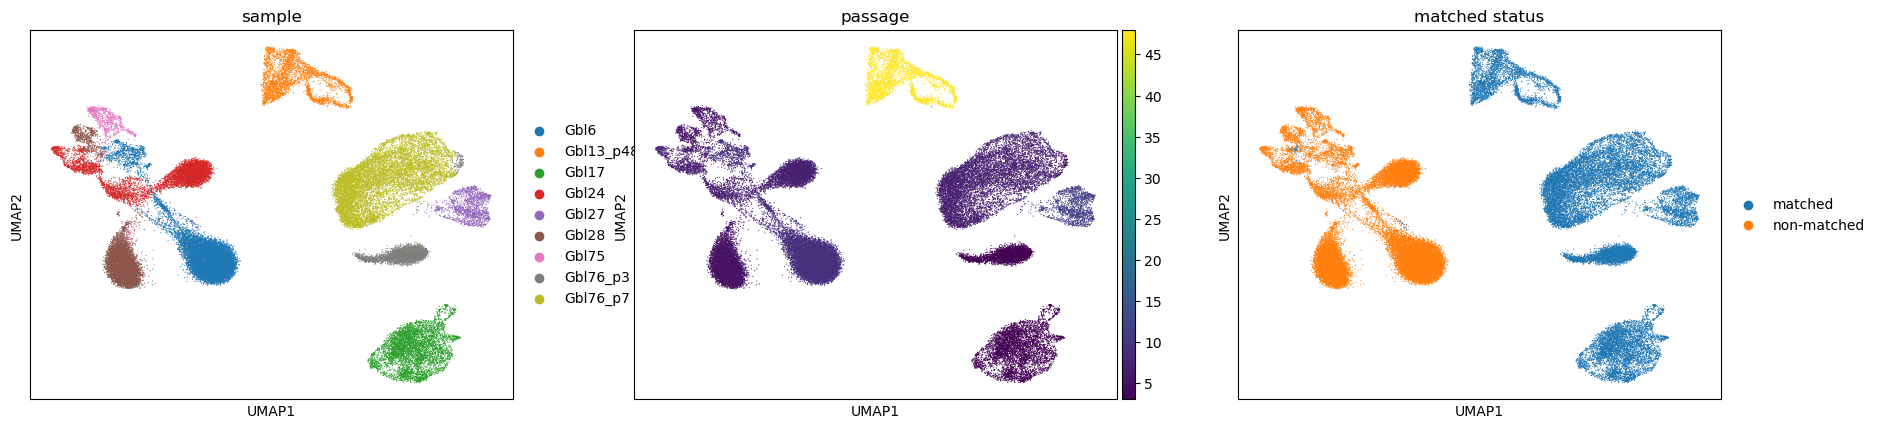

In [10]:
sc.pl.umap(adata_uncor, color=['sample', 'passage', 'matched status'])

**Harmony** batch correction

In [6]:
adata_har = adata.copy()

In [7]:
sc.pp.normalize_total(adata_har, target_sum=1e4)
sc.pp.log1p(adata_har)
sc.pp.highly_variable_genes(adata_har, batch_key='sample')

sc.pp.scale(adata_har) 
sc.tl.pca(adata_har)

normalizing counts per cell
    finished (0:00:00)
extracting highly variable genes


... storing 'sample' as categorical
... storing 'origin' as categorical
... storing 'mutations' as categorical
... storing 'mutations in matched tumor' as categorical
... storing 'matched status' as categorical


    finished (0:00:03)
--> added
    'highly_variable', boolean vector (adata.var)
    'means', float vector (adata.var)
    'dispersions', float vector (adata.var)
    'dispersions_norm', float vector (adata.var)
computing PCA
    with n_comps=50
    finished (0:00:24)


In [8]:
X_pca = adata_har.obsm['X_pca'].astype(np.float64)
ho = hm.run_harmony(X_pca, adata_har.obs, vars_use=['sample'], max_iter_harmony=20)
adata_har.obsm['X_pca_harmony'] = ho.Z_corr  

sc.pp.neighbors(adata_har, use_rep='X_pca_harmony', n_pcs=30)
sc.tl.leiden(adata_har)
sc.tl.umap(adata_har) 

2026-05-12 16:52:35,815 - harmonypy - INFO - Running Harmony (PyTorch on cpu)
Running Harmony (PyTorch on cpu)
2026-05-12 16:52:35,817 - harmonypy - INFO -   Parameters:
  Parameters:
2026-05-12 16:52:35,818 - harmonypy - INFO -     max_iter_harmony: 20
    max_iter_harmony: 20
2026-05-12 16:52:35,819 - harmonypy - INFO -     max_iter_kmeans: 20
    max_iter_kmeans: 20
2026-05-12 16:52:35,820 - harmonypy - INFO -     epsilon_cluster: 1e-05
    epsilon_cluster: 1e-05
2026-05-12 16:52:35,821 - harmonypy - INFO -     epsilon_harmony: 0.0001
    epsilon_harmony: 0.0001
2026-05-12 16:52:35,822 - harmonypy - INFO -     nclust: 100
    nclust: 100
2026-05-12 16:52:35,823 - harmonypy - INFO -     block_size: 0.05
    block_size: 0.05
2026-05-12 16:52:35,824 - harmonypy - INFO -     lamb: [1. 1. 1. 1. 1. 1. 1. 1. 1.]
    lamb: [1. 1. 1. 1. 1. 1. 1. 1. 1.]
2026-05-12 16:52:35,825 - harmonypy - INFO -     theta: [2. 2. 2. 2. 2. 2. 2. 2. 2.]
    theta: [2. 2. 2. 2. 2. 2. 2. 2. 2.]
2026-05-12 16:52

computing neighbors
    finished: added to `.uns['neighbors']`
    `.obsp['distances']`, distances for each pair of neighbors
    `.obsp['connectivities']`, weighted adjacency matrix (0:00:30)
running Leiden clustering
    finished: found 14 clusters and added
    'leiden', the cluster labels (adata.obs, categorical) (0:00:18)
computing UMAP
    finished: added
    'X_umap', UMAP coordinates (adata.obsm)
    'umap', UMAP parameters (adata.uns) (0:00:53)


Clustering

In [3]:
sc.tl.leiden(adata_har, resolution=0.2)

running Leiden clustering
    finished: found 4 clusters and added
    'leiden', the cluster labels (adata.obs, categorical) (0:00:03)


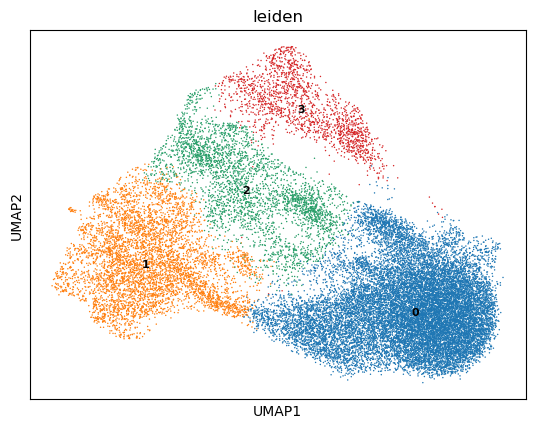

In [4]:
sc.pl.umap(adata_har, color=['leiden'], legend_loc='on data',
           legend_fontsize=8)

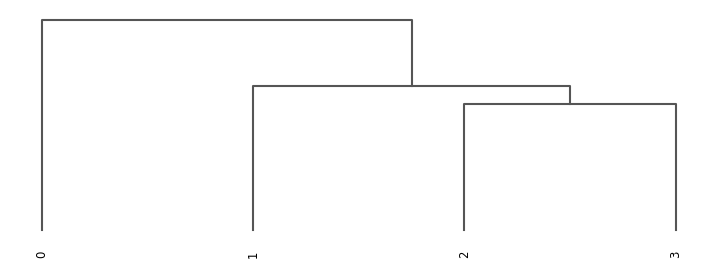

<Axes: >

In [22]:
sc.tl.dendrogram(adata_har, groupby='leiden', n_pcs=15, use_rep='X_pca',
                 linkage_method='single')
fig, ax = plt.subplots(1, 1, figsize=[9, 3])
sc.pl.dendrogram(adata_har, groupby='leiden', ax=ax)

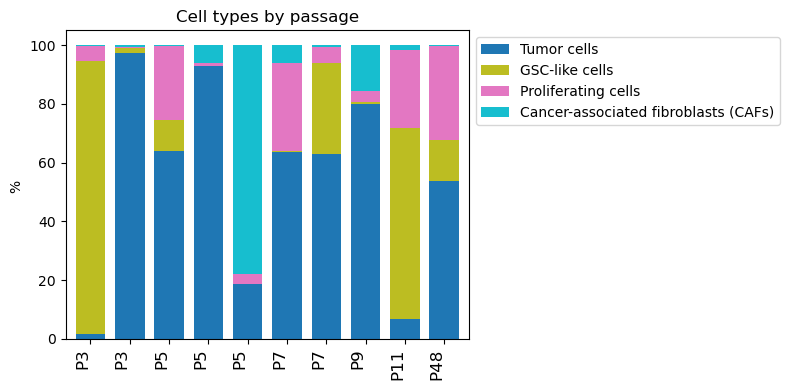

In [ ]:
plt.figure(figsize=(8, 4))  
ct_summary = (adata_har.obs.groupby(['sample', 'manual_celltype_annotation'])
              .size()
              .unstack(fill_value=0)
              .div(adata_har.obs.groupby('sample').size(), axis=0) * 100)

sample_passage = adata_har.obs.groupby('sample')['passage'].first().to_dict()
sorted_samples = sorted(ct_summary.index, key=lambda x: sample_passage[x])
ct_summary_sorted = ct_summary.loc[sorted_samples]

passage_labels = [f"P{sample_passage[samp]}" for samp in sorted_samples]

cell_types = ct_summary_sorted.columns  
colors_list = [color_dict.get(ct, '#cccccc') for ct in cell_types]  
bars = ct_summary_sorted.plot(kind='bar', 
                              stacked=True, 
                              width=0.75,
                              linewidth=1.5,
                              color=colors_list,  
                              ax=plt.gca())

plt.ylabel('% ')
plt.title('Cell types by passage')
plt.xticks(ticks=range(len(passage_labels)), labels=passage_labels, ha='right', fontsize=12)
plt.legend(bbox_to_anchor=(1, 1), loc='upper left', fontsize=10)
plt.xlabel('')
plt.tight_layout()
plt.show()

Annotation using differentially expressed genes

In [19]:
sc.tl.rank_genes_groups(adata_har, groupby='leiden', method='wilcoxon')

ranking genes
    finished: added to `.uns['rank_genes_groups']`
    'names', sorted np.recarray to be indexed by group ids
    'scores', sorted np.recarray to be indexed by group ids
    'logfoldchanges', sorted np.recarray to be indexed by group ids
    'pvals', sorted np.recarray to be indexed by group ids
    'pvals_adj', sorted np.recarray to be indexed by group ids (0:00:36)


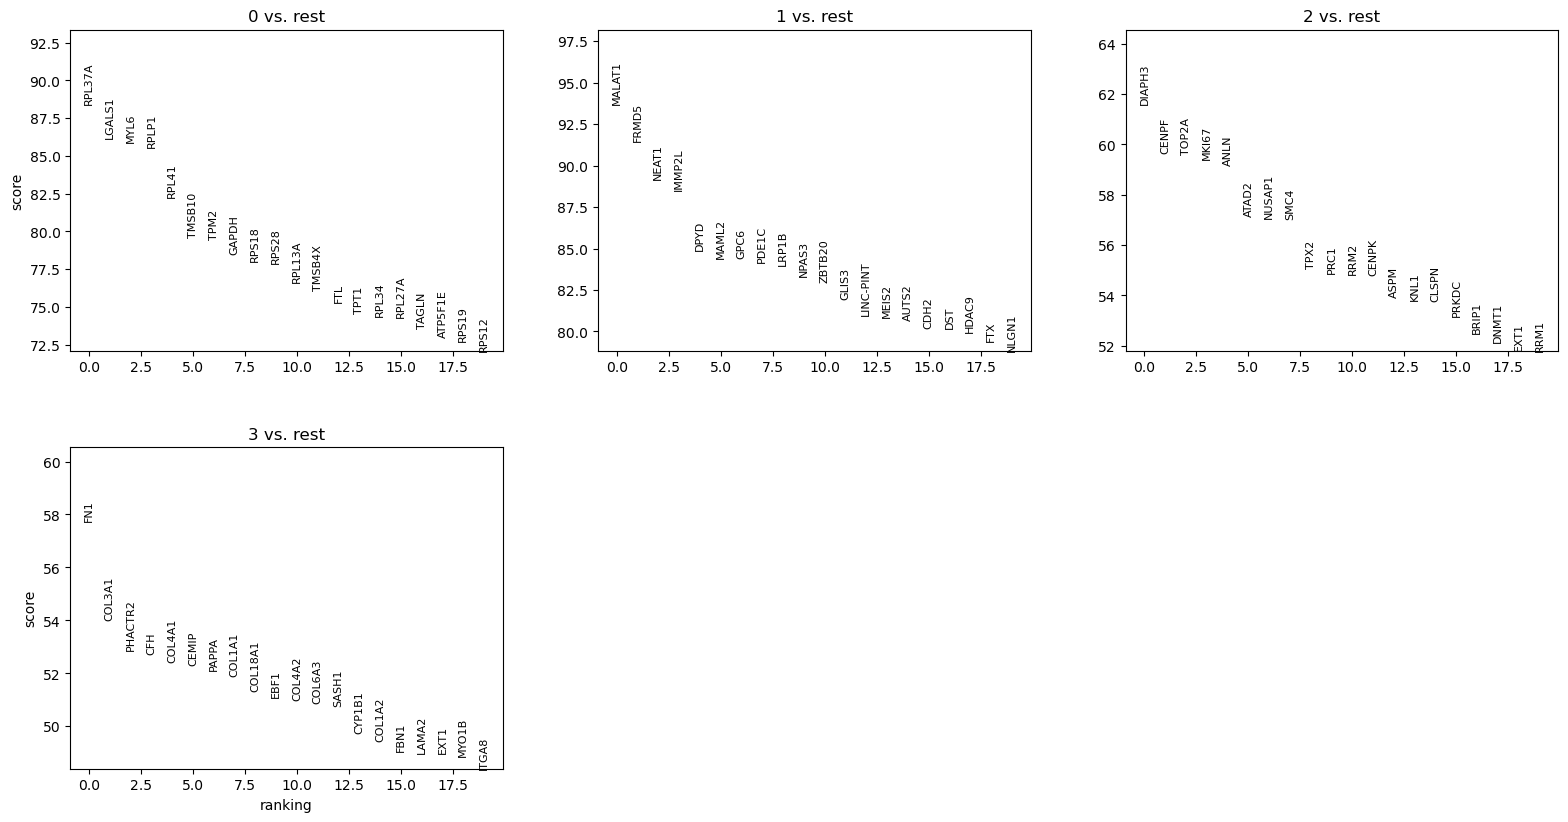

In [20]:
sc.pl.rank_genes_groups(adata_har, n_genes=20, ncols=3, sharey=False)

In [20]:
df = pd.read_excel('12967_2024_5313_MOESM6_ESM.xlsx', sheet_name='Myeloid', header=2)
marker_genes = df.groupby('cluster')['gene'].apply(list).to_dict()

In [42]:
df = pd.read_csv('polycomb_subunits.tsv', sep='\t')
marker_genes = df.groupby('Type')['Name'].apply(list).to_dict()

In [63]:
df = pd.read_csv('../Xie_T_glioblastoma/loop_base_genes.txt', sep='\t')
gene_list = df.iloc[:, 0].tolist() 
marker_genes = { 
    "pc_target": gene_list}

In [9]:
marker_genes = { 
    "GSC-like cells": ["PROM1", "L1CAM", "NES", "THY1", "ITGA6", "CD44", "NANOG", "SOX2"],
    "Tumor cells": ['VIM', 'LDHA', 'CHI3L1', 'LGALS1', 'TMSB10', 'TAGLN', 'S100A6'], 
    "CAFs" :['CCDC80', 'BGN', 'COL5A1', 'COL4A2', 'NR2F2', 'COL3A1', 'INHBA', 'STC2'], 
    "Proliferating cells": ['EZH2', 'CHEK1', 'PCNA', 'TYMS', 'DNMT1', 'TOP2A', 'CENPF', 'MKI67', 'PTTG1', 'UBE2C'], 
}

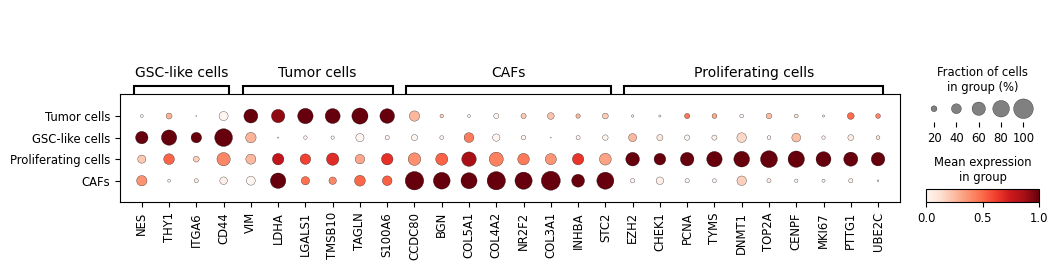

In [12]:
marker_genes_in_data = {}
for ct, markers in marker_genes.items():
    markers_found = []
    for marker in markers:
        if marker in adata_har.var.index:
            markers_found.append(marker)
    marker_genes_in_data[ct] = markers_found


# group_order = ['MES-like', 'CAF', 'Proliferating cells', 'OPC-like', 'AC-like', 'Oligodendrocyte', 'T-cells', 'TAMs']
sc.pl.dotplot(
    adata_har,
    groupby='manual_celltype_annotation',
    var_names=marker_genes_in_data,
    standard_scale="var",
    use_raw=False,
    var_group_rotation=0
)

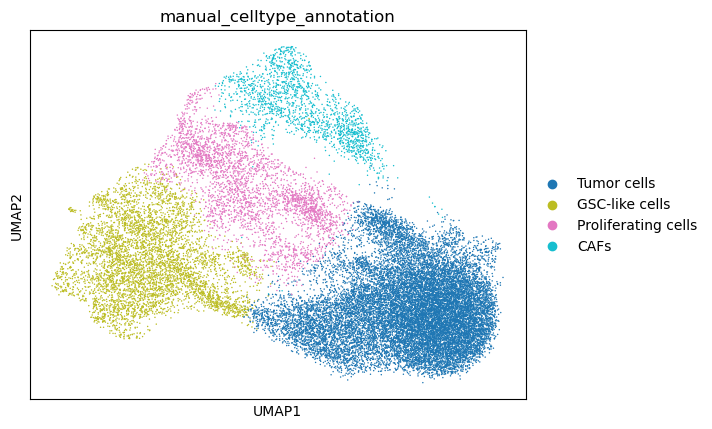

In [10]:
cl_annotation = {
    "0": "Tumor cells", 
    "1": "GSC-like cells",
    "2": "Proliferating cells", 
    "3": "CAFs"
}
adata_har.obs["manual_celltype_annotation"] = adata_har.obs.leiden.map(cl_annotation)
sc.pl.umap(adata_har, color=["manual_celltype_annotation"])

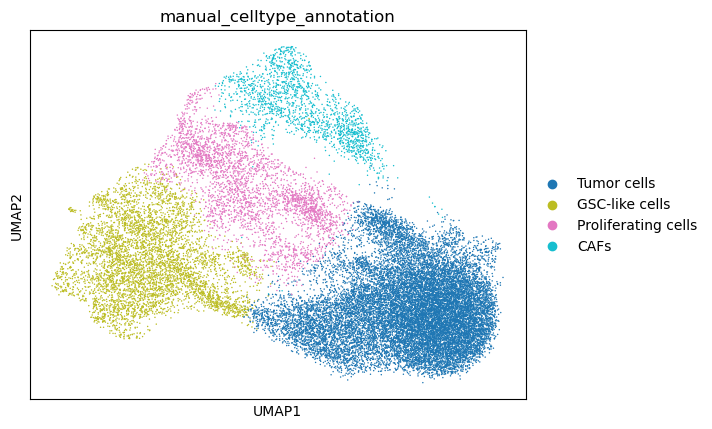

In [11]:
color_dict = {
    "Tumor cells": "#1f77b4",      
    "TAMs": "#ff7f0e",             
    "Oligodendrocyte": "#2ca02c",  
    "T-cells": "#d62728",          
    "GSC-like cells": "#bcbd22",        
    "Proliferating cells": "#e377c2",      
    "CAFs": "#17becf",       
}
adata_har.obs["manual_celltype_annotation"] = adata_har.obs["manual_celltype_annotation"].astype("category")
adata_har.uns["manual_celltype_annotation_colors"] = [
    color_dict[cl] for cl in adata_har.obs["manual_celltype_annotation"].cat.categories
]

sc.pl.umap(adata_har, color="manual_celltype_annotation")

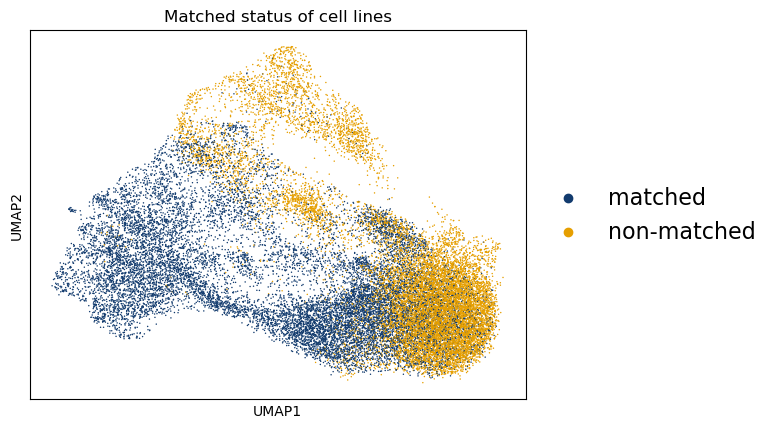

In [17]:
my_colors = ["#123B6E", "#E69F00"]
sc.pl.umap(
    adata_har,
    color=["matched status"],
    title="Matched status of cell lines",
    palette=my_colors, 
    legend_fontsize=16,
)

GO analysis

In [115]:
sc.tl.rank_genes_groups(adata_har, 'cell_type', groups=['unknown'], 
                       reference='rest', method='wilcoxon', use_raw=True)

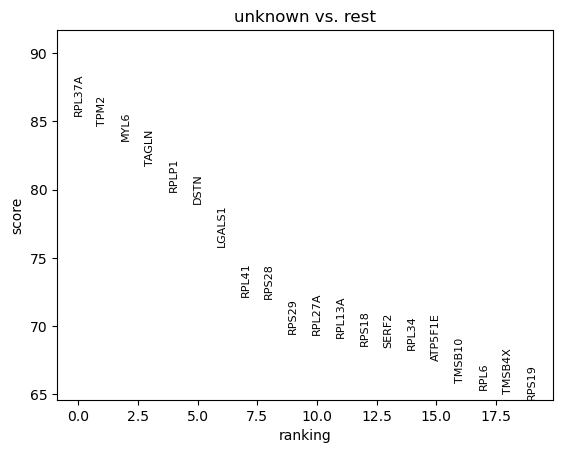

In [116]:
sc.pl.rank_genes_groups(adata_har, n_genes=20, sharey=False)

In [117]:
result = adata_har.uns['rank_genes_groups']
groups = result['names'].dtype.names
degs = pd.DataFrame(
    {key: result[key][group]
    for group in groups for key in ['names','scores', 'pvals','pvals_adj','logfoldchanges']})
degs

,names,scores,pvals,pvals_adj,logfoldchanges
0,RPL37A,85.441994,0.0,0.0,1.070049
1,TPM2,84.712433,0.0,0.0,1.900190
2,MYL6,83.595016,0.0,0.0,1.081997
3,TAGLN,81.775406,0.0,0.0,1.829381
4,RPLP1,79.872116,0.0,0.0,0.824755
...,...,...,...,...,...
16816,PSD3,-99.041489,0.0,0.0,-3.412994
16817,DST,-99.181046,0.0,0.0,-2.679991
16818,LINC-PINT,-99.731934,0.0,0.0,-2.895742
16819,MAML2,-99.858009,0.0,0.0,-3.165361


In [118]:
degs = degs.dropna(subset=['logfoldchanges'])
degs_sig = degs[degs.pvals_adj	 < 0.05]
degs_up = degs_sig[degs_sig.logfoldchanges > 0]
degs_dw = degs_sig[degs_sig.logfoldchanges < 0]
print(degs_up.shape)
print(degs_dw.shape)

(1318, 5)
(14906, 5)


In [119]:
enr_up = gp.enrichr(degs_up.names,
                    gene_sets=['GO_Biological_Process_2025'],
                    outdir=None)
enr_up.res2d.Term = enr_up.res2d.Term.str.split(" \(GO").str[0]
enr_dw = gp.enrichr(degs_dw.names,
                    gene_sets=['GO_Biological_Process_2025'],
                    outdir=None)
enr_dw.res2d.Term = enr_dw.res2d.Term.str.split(" \(GO").str[0]

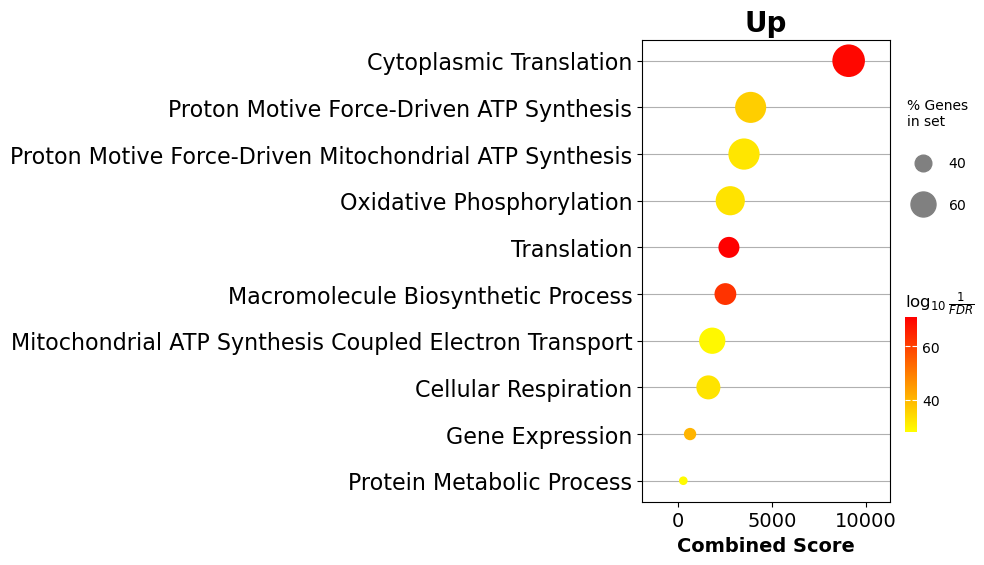

In [120]:
gp.dotplot(enr_up.res2d,
           title="Up",
           cmap = plt.cm.autumn_r)
plt.show()

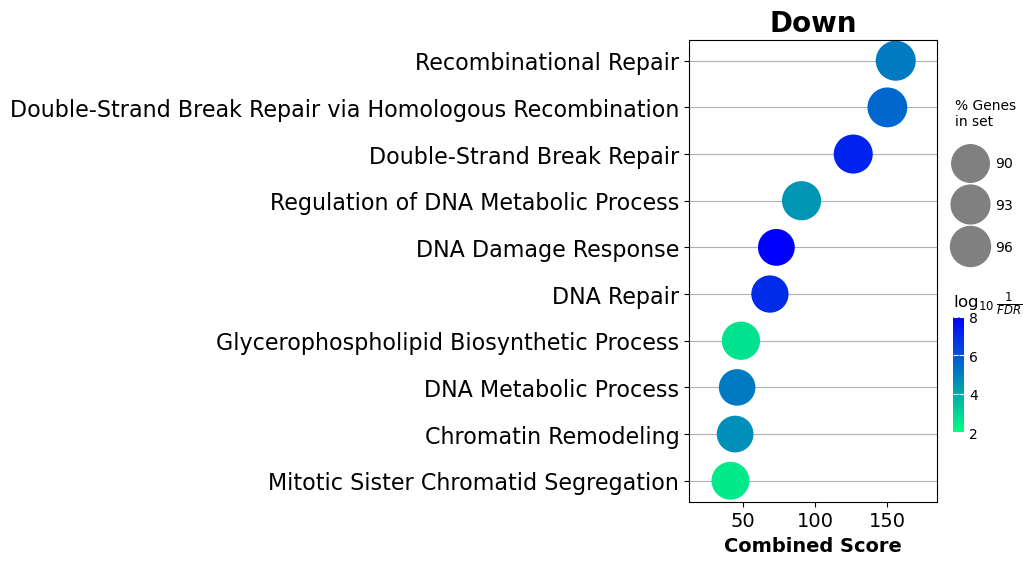

In [121]:
gp.dotplot(enr_dw.res2d,
           title="Down",
           cmap = plt.cm.winter_r)
plt.show()

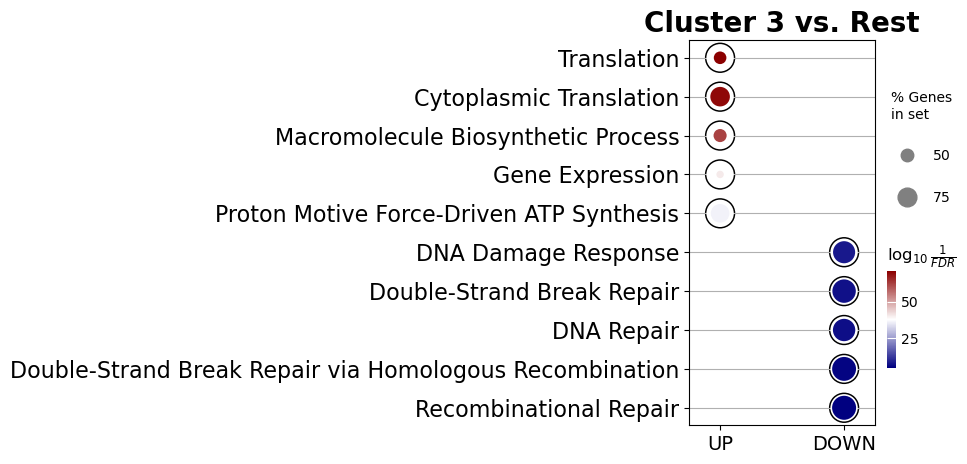

In [122]:
enr_up.res2d['UP_DW'] = "UP"
enr_dw.res2d['UP_DW'] = "DOWN"
enr_res = pd.concat([enr_up.res2d.head(), enr_dw.res2d.head()])
ax = gp.dotplot(enr_res,figsize=(3,5),
                x='UP_DW',
                x_order = ["UP","DOWN"],
                title="Cluster 3 vs. Rest",
                cmap = NbDr, 
                size=3,
                show_ring=True)
ax.set_xlabel("")
plt.show()

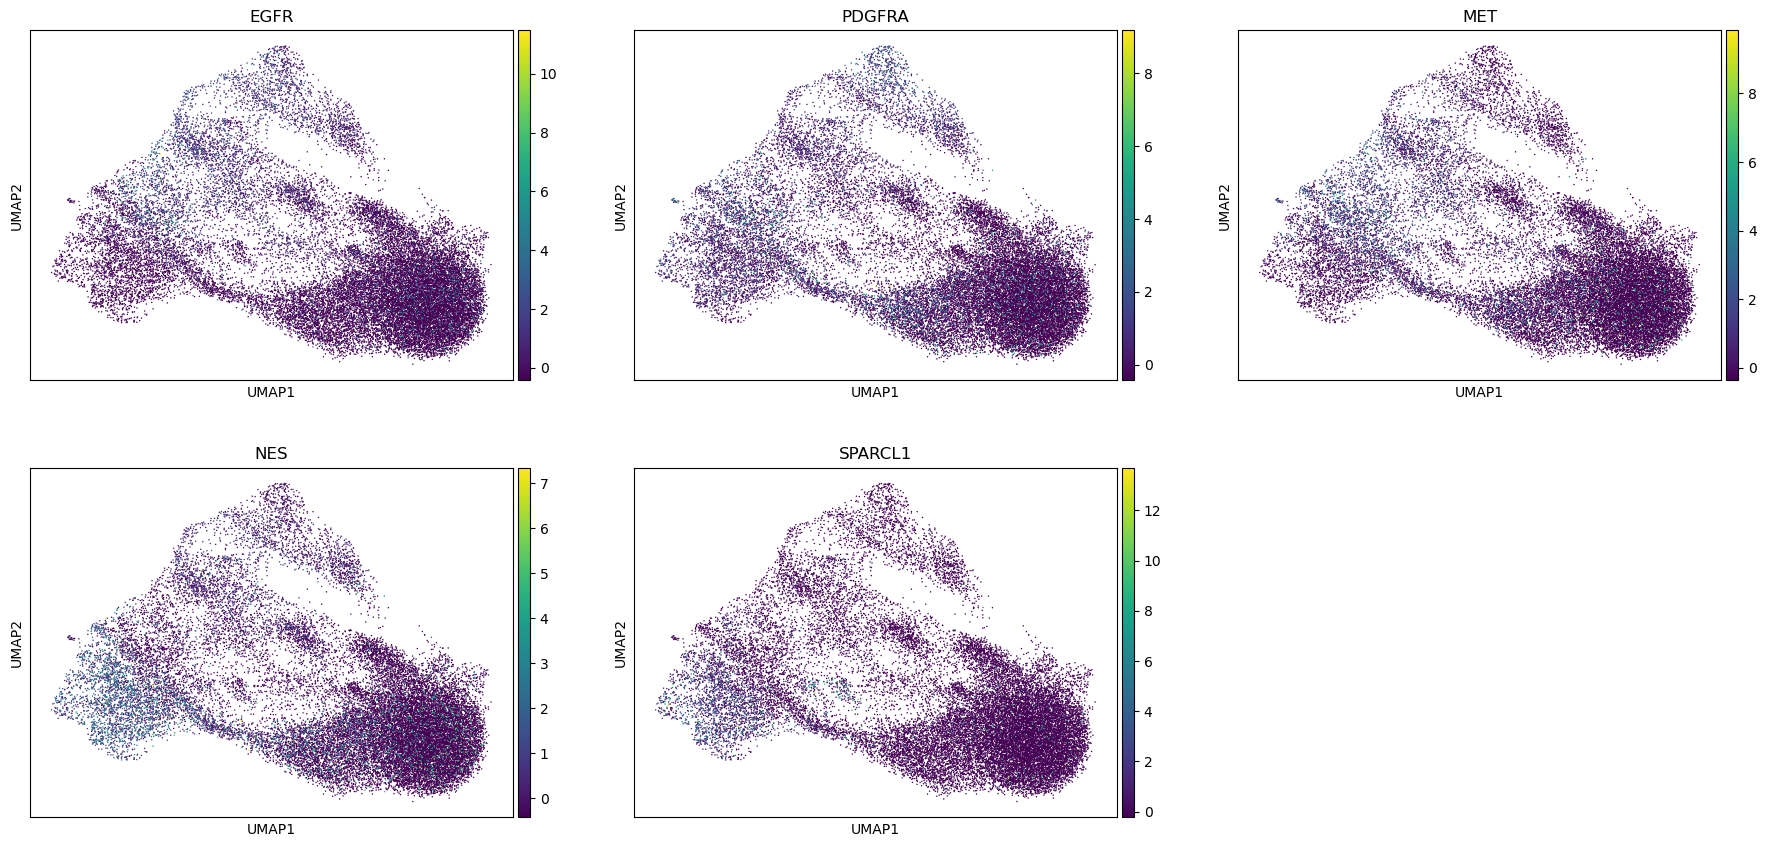

In [6]:
sc.pl.umap(adata_har, color=['EGFR', 'PDGFRA', 'MET', 'NES', 'SPARCL1'], vmax='p90', ncols=3)

Automatic annotation: **Celltypist**

In [126]:
adata.layers['counts'] = adata.X.copy()

In [127]:
adata_celltypist = adata.copy()  # make a copy of our adata
adata_celltypist.X = adata.layers["counts"]  # set adata.X to raw counts
sc.pp.normalize_total(
    adata_celltypist, target_sum=10**4
)  # normalize to 10,000 counts per cell
sc.pp.log1p(adata_celltypist)  # log-transform
# make .X dense instead of sparse, for compatibility with celltypist:
adata_celltypist.X = adata_celltypist.X.toarray()

In [128]:
models.download_models(
    force_update=True,
    model=["Adult_Human_PrefrontalCortex.pkl"] # provide model name
)

📜 Retrieving model list from server https://celltypist.cog.sanger.ac.uk/models/models.json
📚 Total models in list: 60
📂 Storing models in /home/iuliia_parshchikova/.celltypist/data/models
💾 Total models to download: 1
💾 Downloading model [1/1]: Adult_Human_PrefrontalCortex.pkl


In [129]:
model = models.Model.load(model="Adult_Human_PrefrontalCortex.pkl")

In [130]:
model

CellTypist model with 113 cell types and 4304 features
    date: 2024-09-05 11:40:55.636137
    details: cell types and subtypes from the adult human dorsolateral prefrontal cortex
    source: https://doi.org/10.1126/science.abo7257
    version: v1
    cell types: Astro AQP4 OSMR, Astro AQP4 SLC1A2, ..., VLMC SLC47A1 SLC4A4
    features: ISG15, GABRD, ..., GAB3

In [131]:
# Predict cell types from log1p-tranformed counts normalized for sequencing depth
predictions = celltypist.annotate(
    adata_celltypist,
    model=model,
    majority_voting=True
)

🔬 Input data has 28714 cells and 16821 genes
🔗 Matching reference genes in the model
🧬 2560 features used for prediction
⚖️ Scaling input data
🖋️ Predicting labels
✅ Prediction done!
👀 Can not detect a neighborhood graph, will construct one before the over-clustering
⛓️ Over-clustering input data with resolution set to 15
🗳️ Majority voting the predictions
✅ Majority voting done!


In [132]:
predictions_adata = predictions.to_adata()

In [133]:
# Add generated annotation to adata.obs
adata_har.obs["celltypist_cell_label"] = predictions_adata.obs.loc[
    adata_har.obs.index, "majority_voting"
]
adata_har.obs["celltypist_conf_score"] = predictions_adata.obs.loc[
    adata_har.obs.index, "conf_score"
]

In [134]:
adata_har

AnnData object with n_obs × n_vars = 28714 × 16821
    obs: 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb', 'n_genes', 'doublet_score', 'predicted_doublet', 'cell_type', 'sample', 'origin', 'passage', 'mutations', 'mutations in matched tumor', 'matched status', 'leiden', 'AC-like_score1', 'Astrocytes_score1', 'B-cells_score1', 'Endothelial_score1', 'G1/S_score1', 'G2/M_score1', 'MES-like 1_score1', 'MES-like 2_score1', 'NPC-Like 1_score1', 'NPC-Like 2_score1', 'Neurons_score1', 'OPC_score1', 'OPC-Like_score1', 'Oligodendrocytes_score1', 'Pericytes_score1', 'T-cells_score1', 'Tams_score1', 'cell_type1', 'GSCs_score2', 'GBM_type', 'Classical_sc

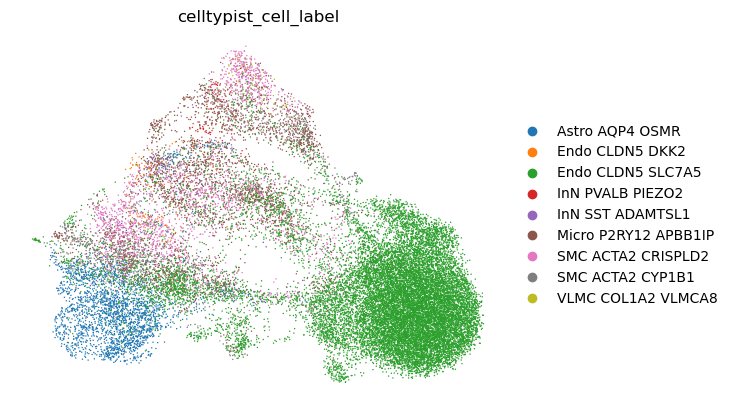

In [135]:
# Visualize results
sc.pl.umap(
    adata_har,
    color=["celltypist_cell_label"],
    frameon=False,
    sort_order=False,
    wspace=1,
)

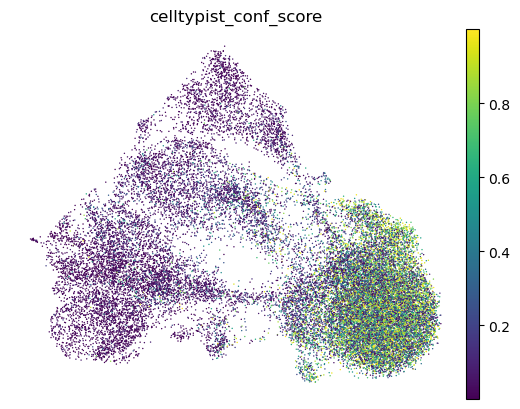

In [136]:
# celltypist confidence score
sc.pl.umap(
    adata_har,
    color=["celltypist_conf_score"],
    frameon=False,
    sort_order=False,
    wspace=1,
)